In [30]:
import geopandas as gpd
from shapely.geometry import Point
import requests

In [31]:
URL = "http://localhost:4000/api/map/wards"
response = requests.get(URL)
wards_gdf = gpd.GeoDataFrame.from_features(response.json()["data"]["features"])

wards_gdf.crs = "EPSG:4326"
wards_gdf.head()

,geometry,fid,ward_no,name,remarks,ward_id,ward_name,population,area_ha,density,councillor,party,municipality
0,"POLYGON ((88.62159 22.8422, 88.62468 22.84811,...",1,10,Girrafe Park area,None,10,Ward 10,12400,26,477,Rekha Pal,AITC,Ashoknagar Kalyangarh Municipality
1,"POLYGON ((88.63923 22.85013, 88.64265 22.84896...",2,8,None,None,8,Ward 8,15600,20,780,Sunita Sarkar,BJP,Ashoknagar Kalyangarh Municipality
2,"POLYGON ((88.64838 22.88332, 88.64861 22.88289...",3,1,None,None,1,Ward 1,11200,28,400,Ratan Kumar Saha,AITC,Ashoknagar Kalyangarh Municipality
3,"POLYGON ((88.62721 22.84851, 88.6274 22.84861,...",4,7,None,None,7,Ward 7,27300,12,2275,Dilip Chakraborty,AITC,Ashoknagar Kalyangarh Municipality
4,"POLYGON ((88.63634 22.85104, 88.63743 22.85425...",5,3,None,None,3,Ward 3,9600,30,320,Sunil Mondal,BJP,Ashoknagar Kalyangarh Municipality


In [32]:
print(wards_gdf.crs)
print(wards_gdf.total_bounds)

EPSG:4326
[88.59509707 22.8102912  88.65784709 22.88383278]


In [33]:
point = Point(88.63733761742397, 22.85270625962288) 
# point = Point(88.63733761742397, 32.85270625962288) 

# 1. Create a tiny GeoDataFrame for your point
point_df = gpd.GeoDataFrame(
    {'geometry': [point]}, 
    crs="EPSG:4326"
)

# 'predicate=intersects' checks if the point is inside or touching the ward
result = gpd.sjoin(point_df, wards_gdf, how="left", predicate="intersects")

# print(result[['ward_no', 'ward_name', 'municipality']])
result["ward_no"][0]

import pandas as pd
# int(result["ward_no"][0])
if pd.isna(result["ward_no"][0]):
    ward_id = None
else:
    ward_id = int(result["ward_no"][0])

print(ward_id)

3


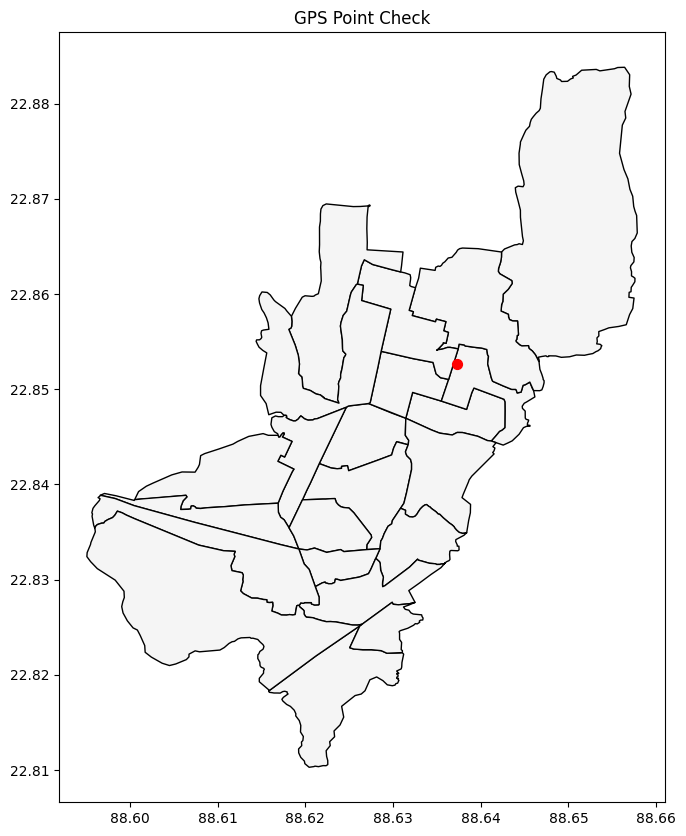

In [34]:
import matplotlib.pyplot as plt

# Plot the wards
ax = wards_gdf.plot(figsize=(10, 10), color='whitesmoke', edgecolor='black')

# Plot your point on the same map in red
point_df.plot(ax=ax, color='red', markersize=50)

plt.title("GPS Point Check")
plt.show()